# Outliers, patrones simples de fraude y detección estadística de anomalías

1. Outliers univariantes — Z-score, IQR y boxplots, variable a variable.
2. Patrones simples de fraude — picos de gasto respecto al historial de cada cliente y transacciones rápidas repetitivas (ráfagas).
3. Técnicas estadísticas para detección de anomalías — combinar varias señales en un score de riesgo y medir cuánto fraude detecta.

En todos los casos las reglas se calculan sin mirar la tabla alerta ni es_fraude; esas dos solo se usan al final de cada apartado para comprobar cuánto aciertan las reglas. Así lo que se mide es la capacidad real de detección, y queda una referencia base con la que comparar los modelos del Hito 3.



## 0. Conexión y configuración

In [2]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

HOST, PORT, USER, PASSWORD, DATABASE = "localhost", 8123, "default", "password", "fraude_pagos"

client = clickhouse_connect.get_client(
    host=HOST, port=PORT, username=USER, password=PASSWORD, database=DATABASE
)
print(f"Conectado a la base de datos \"{DATABASE}\"")


Conectado a la base de datos "fraude_pagos"


# 1.  Identificación de outliers univariantes

Se buscan valores atípicos variable a variable con dos métodos clásicos:

- Z-score: cuántas desviaciones estándar se aleja un valor de la media.
- IQR (rango intercuartílico): IQR = Q3 - Q1. Se marca como outlier si el valor cae fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR].


## 1.1 Función auxiliar: outliers por Z-score e IQR

Recibe una serie numérica, calcula ambos métodos, imprime un resumen y devuelve las máscaras booleanas (para poder cruzarlas después con es_fraude).

In [3]:
def resumen_outliers(nombre, serie, umbral_z=3, k_iqr=1.5):
    serie = serie.dropna().astype(float)
    media, std = serie.mean(), serie.std()
    z = (serie - media) / std
    mask_z = z.abs() > umbral_z

    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k_iqr * iqr, q3 + k_iqr * iqr
    mask_iqr = (serie < lim_inf) | (serie > lim_sup)

    print(f"--- {nombre} ---")
    print(f"n = {len(serie):,}  |  media = {media:.2f}  |  std = {std:.2f}")
    print(f"IQR: Q1={q1:.2f}  Q3={q3:.2f}  límites=[{lim_inf:.2f}, {lim_sup:.2f}]")
    print(f"Outliers por Z-score (|z|>{umbral_z}):  {mask_z.sum():>6,}  ({mask_z.mean() * 100:.2f}%)")
    print(f"Outliers por IQR (k={k_iqr}):          {mask_iqr.sum():>6,}  ({mask_iqr.mean() * 100:.2f}%)")
    print(f"Coinciden en ambos métodos:        {(mask_z & mask_iqr).sum():>6,}")

    return pd.DataFrame({"valor": serie, "outlier_zscore": mask_z, "outlier_iqr": mask_iqr})


## 1.2 transaccion.cantidad

La variable más relevante: importe de cada transacción. Al venir de una lognormal, se espera que el Z-score marque menos outliers que el IQR (la media y la std están "infladas" por la cola larga de importes altos).

--- transaccion.cantidad ---
n = 36,891  |  media = 50.81  |  std = 149.18
IQR: Q1=17.32  Q3=52.33  límites=[-35.17, 104.83]
Outliers por Z-score (|z|>3):     250  (0.68%)
Outliers por IQR (k=1.5):           2,587  (7.01%)
Coinciden en ambos métodos:           250


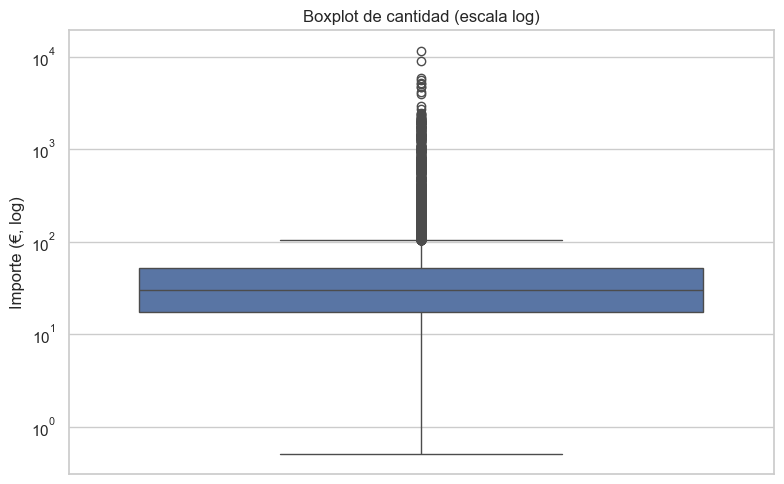

In [4]:
df_txn = client.query_df("SELECT transaccion_id, cantidad, es_fraude FROM transaccion")
df_txn["cantidad"] = df_txn["cantidad"].astype(float)

res_cantidad = resumen_outliers("transaccion.cantidad", df_txn["cantidad"])
df_txn["outlier_zscore"] = res_cantidad["outlier_zscore"].values
df_txn["outlier_iqr"] = res_cantidad["outlier_iqr"].values

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df_txn["cantidad"], ax=ax)
ax.set_yscale("log")
ax.set_title("Boxplot de cantidad (escala log)")
ax.set_ylabel("Importe (€, log)")
plt.tight_layout()
plt.show()


### ¿Los outliers de cantidad coinciden con fraude real?

Con es_fraude se puede comprobar si marcar outliers de importe ya "acierta" con el fraude, sin ningún modelo.

In [5]:
tasa_fraude_general = df_txn["es_fraude"].mean() * 100
print(f"Tasa de fraude general:                        {tasa_fraude_general:.2f}%")
print(f"Tasa de fraude entre outliers por Z-score:     {df_txn.loc[df_txn['outlier_zscore'], 'es_fraude'].mean() * 100:.2f}%")
print(f"Tasa de fraude entre outliers por IQR:         {df_txn.loc[df_txn['outlier_iqr'], 'es_fraude'].mean() * 100:.2f}%")

recall_z = df_txn.loc[df_txn["es_fraude"] == 1, "outlier_zscore"].mean() * 100
recall_iqr = df_txn.loc[df_txn["es_fraude"] == 1, "outlier_iqr"].mean() * 100
print(f"\n% del fraude real que detecta el Z-score de cantidad:  {recall_z:.1f}%")
print(f"% del fraude real que detecta el IQR de cantidad:      {recall_iqr:.1f}%")


Tasa de fraude general:                        1.96%
Tasa de fraude entre outliers por Z-score:     96.80%
Tasa de fraude entre outliers por IQR:         15.81%

% del fraude real que detecta el Z-score de cantidad:  33.4%
% del fraude real que detecta el IQR de cantidad:      56.5%


## 1.3 cantidad en escala logarítmica

Cuando una variable está muy sesgada (lognormal), una técnica estadística habitual es aplicar el logaritmo antes de buscar outliers: log(cantidad) tiene forma de campana (aproximadamente normal), y ahí tanto el Z-score como el IQR funcionan como se supone que deben funcionar.

Además, en escala log los outliers aparecen por los dos lados: importes anormalmente altos (picos) y también anormalmente bajos (como los céntimos del card testing), que en escala normal quedaban "pegados" al 0 y nunca salían como outliers.

--- log(transaccion.cantidad) ---
n = 36,891  |  media = 3.41  |  std = 0.90
IQR: Q1=2.85  Q3=3.96  límites=[1.19, 5.62]
Outliers por Z-score (|z|>3):     556  (1.51%)
Outliers por IQR (k=1.5):             790  (2.14%)
Coinciden en ambos métodos:           556


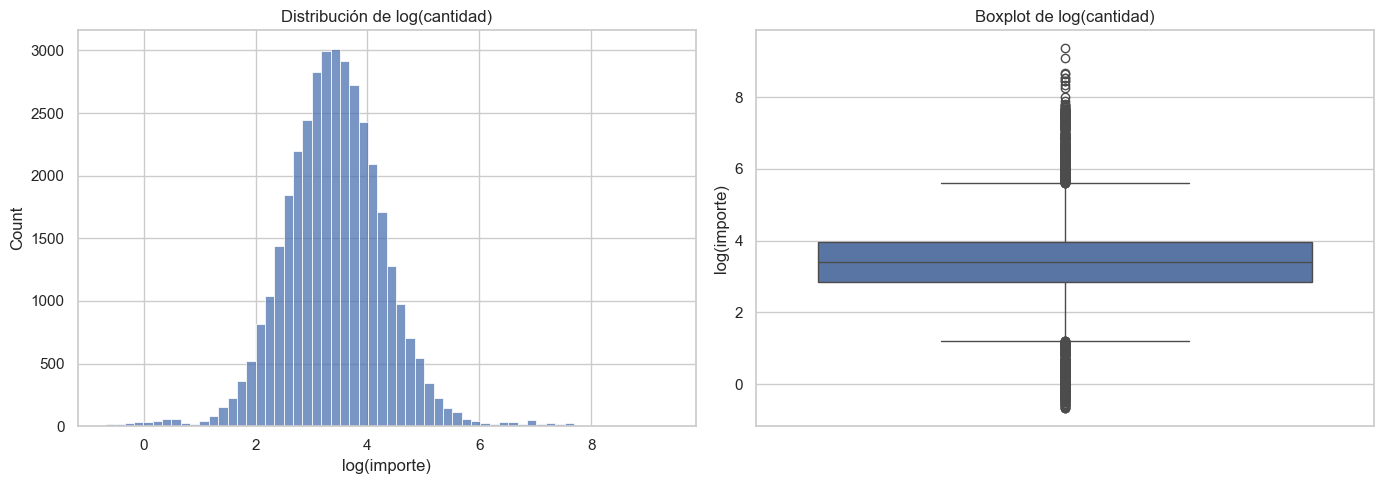

In [7]:
df_txn["log_cantidad"] = np.log(df_txn["cantidad"])

res_log = resumen_outliers("log(transaccion.cantidad)", df_txn["log_cantidad"])
df_txn["outlier_zscore_log"] = res_log["outlier_zscore"].values
df_txn["outlier_iqr_log"] = res_log["outlier_iqr"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_txn["log_cantidad"], bins=60, ax=axes[0])
axes[0].set_title("Distribución de log(cantidad)")
axes[0].set_xlabel("log(importe)")
sns.boxplot(y=df_txn["log_cantidad"], ax=axes[1])
axes[1].set_title("Boxplot de log(cantidad)")
axes[1].set_ylabel("log(importe)")
plt.tight_layout()
plt.show()


In [7]:
q1_log, q3_log = df_txn["log_cantidad"].quantile([0.25, 0.75])
lim_inf_log = q1_log - 1.5 * (q3_log - q1_log)
print(f"Outliers bajos por IQR (importe < {np.exp(lim_inf_log):.2f} €): {(df_txn['log_cantidad'] < lim_inf_log).sum():,}")
print(f"Outliers altos por IQR:                          {(df_txn['outlier_iqr_log'] & (df_txn['log_cantidad'] > lim_inf_log)).sum():,}")

comparativa = pd.DataFrame([
    {"método": nombre,
     "outliers": int(df_txn[col].sum()),
     "tasa_fraude_entre_outliers_%": round(df_txn.loc[df_txn[col], "es_fraude"].mean() * 100, 1),
     "%_del_fraude_detectado": round(df_txn.loc[df_txn["es_fraude"] == 1, col].mean() * 100, 1)}
    for nombre, col in [("Z-score (escala normal)", "outlier_zscore"),
                        ("IQR (escala normal)", "outlier_iqr"),
                        ("Z-score (escala log)", "outlier_zscore_log"),
                        ("IQR (escala log)", "outlier_iqr_log")]
])
comparativa


Outliers bajos por IQR (importe < 3.30 €): 370
Outliers altos por IQR:                          420


,método,outliers,tasa_fraude_entre_outliers_%,%_del_fraude_detectado
0,Z-score (escala normal),250,96.8,33.4
1,IQR (escala normal),2587,15.8,56.5
2,Z-score (escala log),556,95.1,73.1
3,IQR (escala log),790,73.0,79.7


## 1.4 sesion.num_intentos_login

Variable discreta y muy concentrada en 1 (login a la primera). Cuando casi todos los valores son iguales, Q1 = Q3 y el IQR = 0, así que cualquier valor distinto de 1 sale como outlier por IQR — es un caso típico en el que conviene mirar ambos métodos y no fiarse de uno solo.

--- sesion.num_intentos_login ---
n = 36,626  |  media = 1.01  |  std = 0.17
IQR: Q1=1.00  Q3=1.00  límites=[1.00, 1.00]
Outliers por Z-score (|z|>3):      45  (0.12%)
Outliers por IQR (k=1.5):              45  (0.12%)
Coinciden en ambos métodos:            45


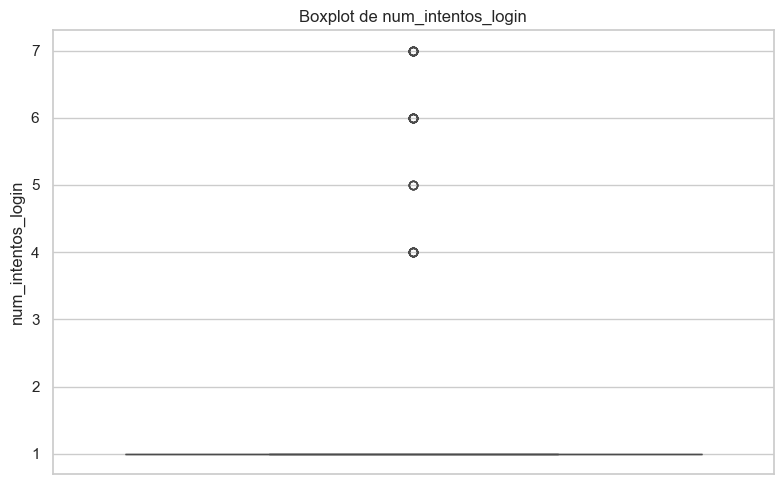


Sesiones por nº de intentos de login:
num_intentos_login
1    36581
4       12
5        5
6       13
7       15


In [8]:
df_ses = client.query_df("SELECT sesion_id, num_intentos_login FROM sesion")

res_login = resumen_outliers("sesion.num_intentos_login", df_ses["num_intentos_login"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df_ses["num_intentos_login"], ax=ax)
ax.set_title("Boxplot de num_intentos_login")
plt.tight_layout()
plt.show()

print("\nSesiones por nº de intentos de login:")
print(df_ses["num_intentos_login"].value_counts().sort_index().to_string())


## 1.5 `metodo_pago.limite_credito`

Solo aplica a tarjetas de crédito (en débito es nulo). El límite se genera con un rango uniforme (1.000-15.000€), así que no se esperan outliers: sirve como control de calidad de los datos generados.

--- metodo_pago.limite_credito (solo crédito) ---
n = 2,173  |  media = 8055.25  |  std = 4097.01
IQR: Q1=4402.00  Q3=11651.00  límites=[-6471.50, 22524.50]
Outliers por Z-score (|z|>3):       0  (0.00%)
Outliers por IQR (k=1.5):               0  (0.00%)
Coinciden en ambos métodos:             0


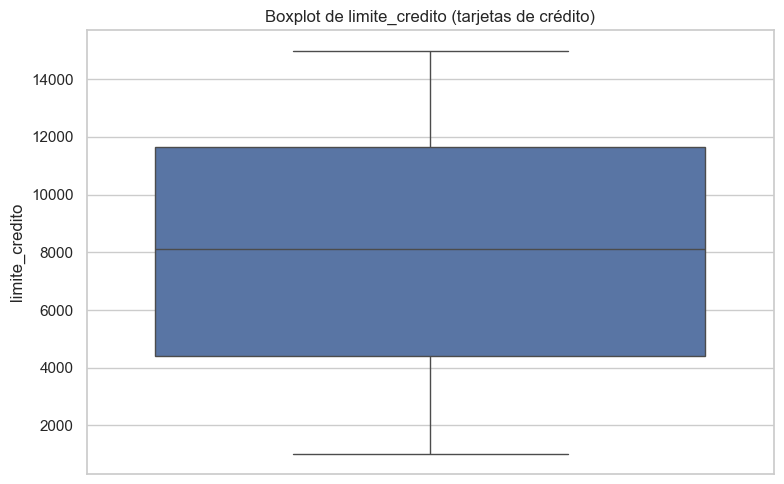

In [9]:
df_metodo = client.query_df("SELECT metodo_id, limite_credito FROM metodo_pago WHERE tipo = 'credito'")
df_metodo["limite_credito"] = df_metodo["limite_credito"].astype(float)

res_limite = resumen_outliers("metodo_pago.limite_credito (solo crédito)", df_metodo["limite_credito"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df_metodo["limite_credito"], ax=ax)
ax.set_title("Boxplot de limite_credito (tarjetas de crédito)")
plt.tight_layout()
plt.show()


## 1.6 `alerta.nota_riesgo`

Todas las filas de `alerta` son ya fraude, así que aquí no se cruza con `es_fraude`: lo interesante es ver si hay alertas con una nota de riesgo especialmente extrema dentro del propio conjunto.

--- alerta.nota_riesgo ---
n = 724  |  media = 0.73  |  std = 0.09
IQR: Q1=0.65  Q3=0.80  límites=[0.42, 1.03]
Outliers por Z-score (|z|>3):       0  (0.00%)
Outliers por IQR (k=1.5):               0  (0.00%)
Coinciden en ambos métodos:             0


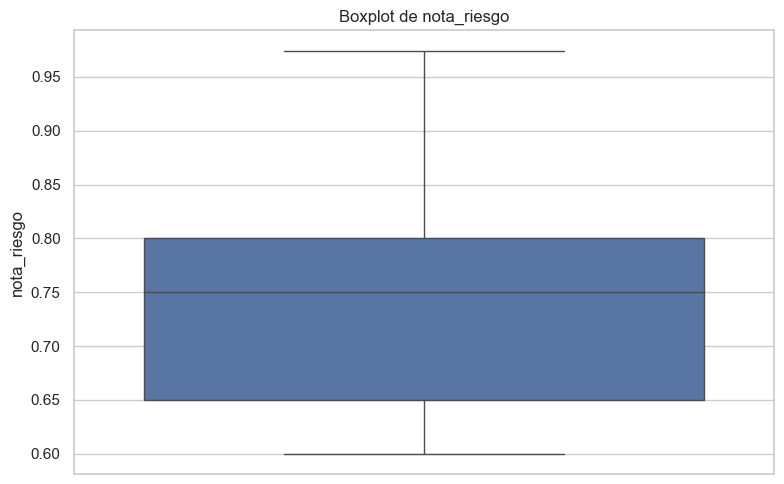

In [10]:
df_alerta = client.query_df("SELECT alerta_id, nota_riesgo FROM alerta")

res_riesgo = resumen_outliers("alerta.nota_riesgo", df_alerta["nota_riesgo"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=df_alerta["nota_riesgo"], ax=ax)
ax.set_title("Boxplot de nota_riesgo")
plt.tight_layout()
plt.show()


## 1.6 Resumen comparativo de outliers univariantes

In [11]:
resumen_general = pd.DataFrame([
    {"variable": nombre, "n": len(res),
     "outliers_zscore": int(res["outlier_zscore"].sum()),
     "outliers_iqr": int(res["outlier_iqr"].sum())}
    for nombre, res in [
        ("transaccion.cantidad", res_cantidad),
        ("log(transaccion.cantidad)", res_log),
        ("sesion.num_intentos_login", res_login),
        ("metodo_pago.limite_credito", res_limite),
        ("alerta.nota_riesgo", res_riesgo),
    ]
])
resumen_general["pct_zscore"] = (resumen_general["outliers_zscore"] / resumen_general["n"] * 100).round(2)
resumen_general["pct_iqr"] = (resumen_general["outliers_iqr"] / resumen_general["n"] * 100).round(2)
resumen_general


,variable,n,outliers_zscore,outliers_iqr,pct_zscore,pct_iqr
0,transaccion.cantidad,36891,250,2587,0.68,7.01
1,log(transaccion.cantidad),36891,556,790,1.51,2.14
2,sesion.num_intentos_login,36626,45,45,0.12,0.12
3,metodo_pago.limite_credito,2173,0,0,0.00,0.00
4,alerta.nota_riesgo,724,0,0,0.00,0.00


# Parte 2 — Análisis de patrones simples de fraude

En la Parte 1 cada variable se miraba "en global" (comparada con todas las transacciones). Aquí se da un paso más y se buscan dos patrones clásicos de fraude con reglas estadísticas sencillas:

- **Picos de gasto**: una transacción anormalmente alta **para ese cliente concreto** (no para el conjunto). 300€ puede ser normal para un cliente y un pico enorme para otro que siempre gasta 20€.
- **Transacciones rápidas repetitivas (ráfagas)**: muchas transacciones seguidas con la misma tarjeta en muy poco tiempo, típico del *card testing*.

## 2.0 Tabla base y función de evaluación

Se construye una tabla con una fila por transacción y todo lo necesario para las partes 2 y 3 (cliente, sesión, dispositivo...). La columna `patron` (tipo de fraude según `alerta`) **no se usa para calcular ninguna regla**, solo para ver después qué tipos de fraude detecta cada una.

Para medir cada regla se usan dos métricas:
- **Precisión**: de las transacciones que marca la regla, qué % son fraude de verdad (cuantas menos falsas alarmas, más alta).
- **Recall (sensibilidad)**: de todo el fraude real, qué % detecta la regla (cuanto menos fraude se escapa, más alto).
- **F1**: media armónica de ambas, un único número para comparar reglas.

In [12]:
# Alias explícitos (AS ...) en todas las columnas: varias tablas comparten nombres
# (timestamp, estado, dispositivo_id...) y sin alias ClickHouse devuelve columnas
# llamadas "t.timestamp", "t.estado"... en vez de "timestamp", "estado"...
df_base = client.query_df("""
    SELECT t.transaccion_id AS transaccion_id, t.timestamp AS timestamp,
           t.cantidad AS cantidad, t.estado AS estado, t.es_fraude AS es_fraude,
           t.metodo_id AS metodo_id, t.dispositivo_id AS dispositivo_id,
           m.cliente_id AS cliente_id,
           s.ip_pais AS ip_pais, s.proxy_vpn AS proxy_vpn,
           s.num_intentos_login AS num_intentos_login,
           d.tipo AS tipo_dispositivo
    FROM transaccion t
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
    JOIN sesion s      ON t.sesion_id = s.sesion_id
    JOIN dispositivo d ON t.dispositivo_id = d.dispositivo_id
""")
df_base["cantidad"] = df_base["cantidad"].astype(float)
df_base["log_cantidad"] = np.log(df_base["cantidad"])
df_base["timestamp"] = pd.to_datetime(df_base["timestamp"])
df_base["es_fraude"] = df_base["es_fraude"].astype(int)

patrones = client.query_df("""
    SELECT a.transaccion_id, p.nombre AS patron
    FROM alerta a
    JOIN patron p ON a.patron_id = p.patron_id
""")
df_base = df_base.merge(patrones, on="transaccion_id", how="left")
df_base["patron"] = df_base["patron"].fillna("normal")

print(f"{len(df_base):,} transacciones cargadas  |  fraude: {df_base['es_fraude'].sum():,} "
      f"({df_base['es_fraude'].mean() * 100:.2f}%)")


36,891 transacciones cargadas  |  fraude: 724 (1.96%)


In [13]:
def evaluar_regla(nombre, marcada, etiqueta):
    marcada = pd.Series(marcada).astype(bool).values
    etiqueta = pd.Series(etiqueta).astype(bool).values
    vp = int((marcada & etiqueta).sum())    # verdaderos positivos: fraude bien detectado
    fp = int((marcada & ~etiqueta).sum())   # falsos positivos: falsas alarmas
    fn = int((~marcada & etiqueta).sum())   # falsos negativos: fraude que se escapa
    precision = vp / (vp + fp) if (vp + fp) else 0.0
    recall = vp / (vp + fn) if (vp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"regla": nombre, "marcadas": int(marcada.sum()), "fraude_detectado": vp,
            "falsas_alarmas": fp, "fraude_escapado": fn,
            "precision_%": round(precision * 100, 1), "recall_%": round(recall * 100, 1),
            "f1": round(f1, 3)}


## 2.1 Picos de gasto respecto al historial del cliente

Para cada cliente se calcula su gasto "típico" y se mide cuánto se aleja cada transacción. En vez del Z-score clásico (media y std) se usa su **versión robusta**, con la **mediana** y la **MAD** (desviación absoluta mediana):

`z_robusto = 0.6745 · (x - mediana_cliente) / MAD_cliente`

- ¿Por qué robusta? Porque el propio pico de gasto infla la media y la std del cliente y se "esconde" a sí mismo; la mediana y la MAD apenas se mueven por un valor extremo.
- Se calcula sobre `log(cantidad)` por lo visto en el apartado 1.3: en escala log los importes de cada cliente son aproximadamente simétricos y el z robusto no se dispara con la cola larga normal de la lognormal.
- El umbral habitual para el z robusto es **3.5**. Solo se aplica a clientes con al menos 5 transacciones, para que su historial sea representativo.

In [14]:
UMBRAL_Z_ROBUSTO = 3.5
MIN_TXN_CLIENTE = 5

g = df_base.groupby("cliente_id")["log_cantidad"]
df_base["n_txn_cliente"] = g.transform("count")
df_base["mediana_cliente"] = g.transform("median")
df_base["mad_cliente"] = g.transform(lambda x: (x - x.median()).abs().median())

df_base["z_robusto_cliente"] = (0.6745 * (df_base["log_cantidad"] - df_base["mediana_cliente"])
                                / df_base["mad_cliente"].replace(0, np.nan))
df_base["pico_gasto"] = ((df_base["n_txn_cliente"] >= MIN_TXN_CLIENTE)
                         & (df_base["z_robusto_cliente"] > UMBRAL_Z_ROBUSTO))

print(f"Transacciones de clientes con >= {MIN_TXN_CLIENTE} transacciones: "
      f"{(df_base['n_txn_cliente'] >= MIN_TXN_CLIENTE).mean() * 100:.1f}%")
print(f"Transacciones marcadas como pico de gasto: {df_base['pico_gasto'].sum():,} "
      f"({df_base['pico_gasto'].mean() * 100:.2f}%)")


Transacciones de clientes con >= 5 transacciones: 100.0%
Transacciones marcadas como pico de gasto: 314 (0.85%)


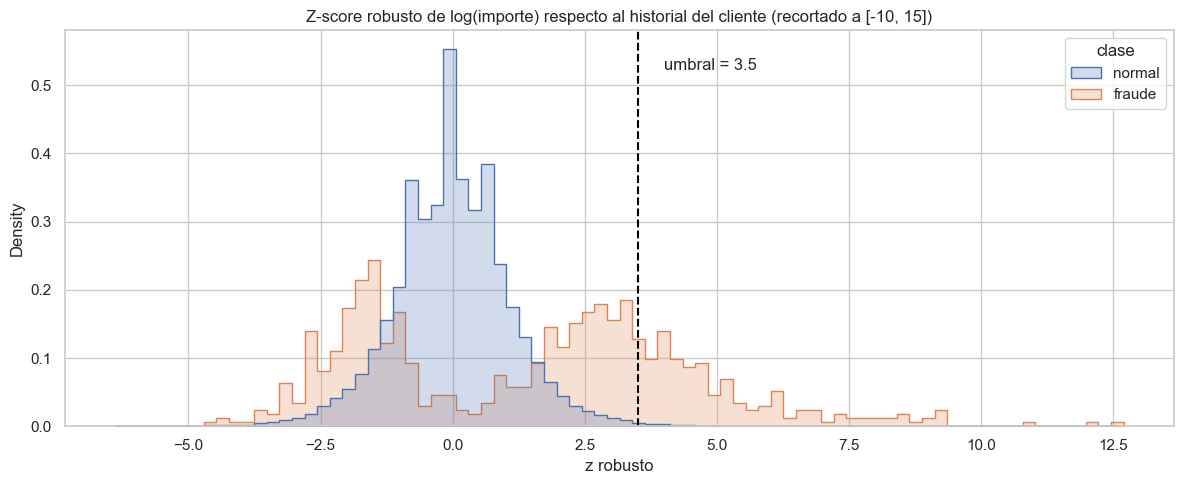

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
datos_plot = df_base.dropna(subset=["z_robusto_cliente"]).copy()
datos_plot["clase"] = np.where(datos_plot["es_fraude"] == 1, "fraude", "normal")
datos_plot["z_recortado"] = datos_plot["z_robusto_cliente"].clip(-10, 15)
sns.histplot(data=datos_plot, x="z_recortado", hue="clase", bins=80, stat="density",
             common_norm=False, element="step", ax=ax)
ax.axvline(UMBRAL_Z_ROBUSTO, color="black", linestyle="--")
ax.text(UMBRAL_Z_ROBUSTO + 0.5, ax.get_ylim()[1] * 0.9, f"umbral = {UMBRAL_Z_ROBUSTO}")
ax.set_title("Z-score robusto de log(importe) respecto al historial del cliente (recortado a [-10, 15])")
ax.set_xlabel("z robusto")
plt.tight_layout()
plt.show()


In [16]:
pd.DataFrame([evaluar_regla("pico de gasto (z robusto > 3.5)", df_base["pico_gasto"], df_base["es_fraude"])])


,regla,marcadas,fraude_detectado,falsas_alarmas,fraude_escapado,precision_%,recall_%,f1
0,pico de gasto (z robusto > 3.5),314,179,135,545,57.0,24.7,0.345


## 2.2 Transacciones rápidas repetitivas (ráfagas)

Para cada método de pago (tarjeta) se ordenan sus transacciones en el tiempo y se calcula cuántos segundos pasan desde la anterior. Después se agrupan en **rachas**: transacciones consecutivas separadas por menos de 60 segundos. Una racha de 5 o más transacciones se marca como **ráfaga**.

Una persona real rara vez paga 5 veces con la misma tarjeta en pocos minutos; un bot probando si una tarjeta robada funciona (*card testing*), sí.

In [17]:
UMBRAL_SEG = 60        # separación máxima entre dos transacciones de la misma racha
MIN_TXN_RAFAGA = 5     # tamaño mínimo de racha para considerarla ráfaga

df_base = df_base.sort_values(["metodo_id", "timestamp"]).reset_index(drop=True)
df_base["seg_desde_anterior"] = df_base.groupby("metodo_id")["timestamp"].diff().dt.total_seconds()

nueva_racha = df_base["seg_desde_anterior"].isna() | (df_base["seg_desde_anterior"] > UMBRAL_SEG)
df_base["id_racha"] = nueva_racha.cumsum()
df_base["tam_racha"] = df_base.groupby("id_racha")["transaccion_id"].transform("count")
df_base["rafaga"] = df_base["tam_racha"] >= MIN_TXN_RAFAGA

print(f"Rachas de >= {MIN_TXN_RAFAGA} transacciones encontradas: "
      f"{df_base.loc[df_base['rafaga'], 'id_racha'].nunique():,}")
print(f"Transacciones dentro de una ráfaga: {df_base['rafaga'].sum():,}")


Rachas de >= 5 transacciones encontradas: 33
Transacciones dentro de una ráfaga: 275


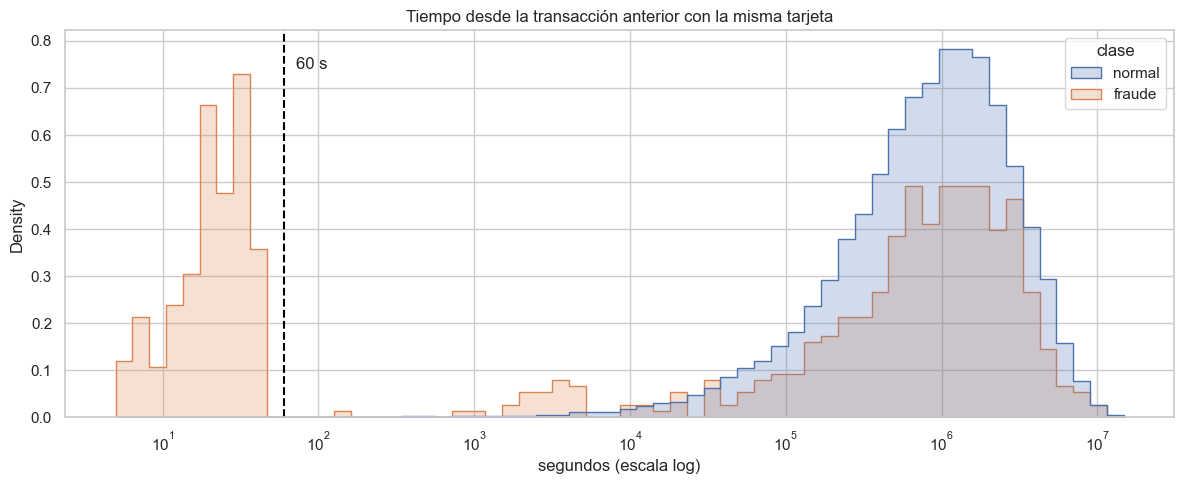

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
datos_plot = df_base.dropna(subset=["seg_desde_anterior"]).copy()
datos_plot = datos_plot[datos_plot["seg_desde_anterior"] > 0]
datos_plot["clase"] = np.where(datos_plot["es_fraude"] == 1, "fraude", "normal")
sns.histplot(data=datos_plot, x="seg_desde_anterior", hue="clase", bins=60, log_scale=True,
             stat="density", common_norm=False, element="step", ax=ax)
ax.axvline(UMBRAL_SEG, color="black", linestyle="--")
ax.text(UMBRAL_SEG * 1.2, ax.get_ylim()[1] * 0.9, f"{UMBRAL_SEG} s")
ax.set_title("Tiempo desde la transacción anterior con la misma tarjeta")
ax.set_xlabel("segundos (escala log)")
plt.tight_layout()
plt.show()


In [19]:
pd.DataFrame([evaluar_regla(f"ráfaga (>= {MIN_TXN_RAFAGA} txn separadas < {UMBRAL_SEG}s)",
                             df_base["rafaga"], df_base["es_fraude"])])


,regla,marcadas,fraude_detectado,falsas_alarmas,fraude_escapado,precision_%,recall_%,f1
0,ráfaga (>= 5 txn separadas < 60s),275,275,0,449,100.0,38.0,0.551


## 2.3 ¿Qué tipos de fraude detecta cada patrón?

Porcentaje de las transacciones fraudulentas de cada tipo que detecta cada regla. Deja claro que cada regla está especializada en unos tipos de fraude y es "ciega" para otros — por eso en la Parte 3 se combinan.

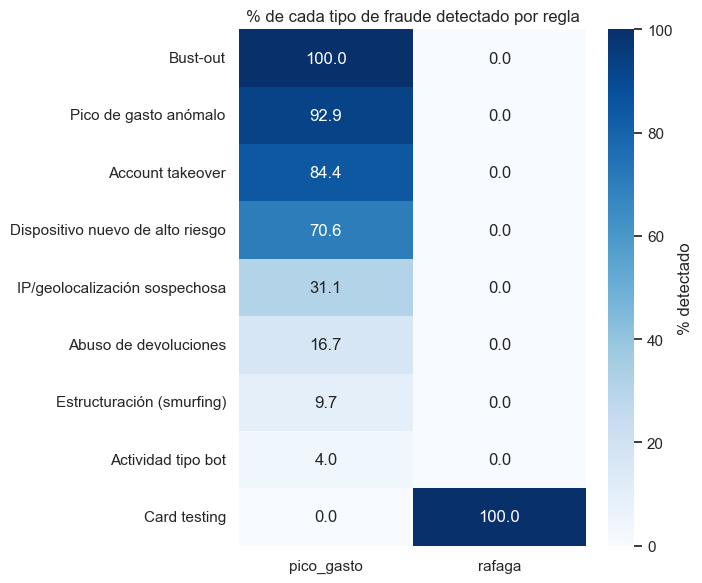

Nº de transacciones fraudulentas por tipo:
patron
Card testing                        275
IP/geolocalización sospechosa       135
Dispositivo nuevo de alto riesgo    102
Actividad tipo bot                  100
Account takeover                     45
Estructuración (smurfing)            31
Abuso de devoluciones                18
Pico de gasto anómalo                14
Bust-out                              4


In [20]:
por_patron = (df_base[df_base["es_fraude"] == 1]
              .groupby("patron")[["pico_gasto", "rafaga"]]
              .mean().mul(100).round(1)
              .sort_values("pico_gasto", ascending=False))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(por_patron, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude detectado por regla")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Nº de transacciones fraudulentas por tipo:")
print(df_base.loc[df_base["es_fraude"] == 1, "patron"].value_counts().to_string())


# Parte 3 — Técnicas estadísticas para detección de anomalías

Ninguna regla por sí sola detecta todo el fraude. La idea aquí es construir varias **señales** estadísticas sencillas (cada una es un sí/no) y sumarlas en un **score de anomalía**: cuantas más señales se activan a la vez en una transacción, más sospechosa es. Es el mismo principio que usan muchos sistemas antifraude basados en reglas antes de pasar a Machine Learning.

## 3.1 Construcción de señales

| Señal | Técnica estadística | Qué captura |
|---|---|---|
| `outlier_importe` | IQR global sobre `log(cantidad)` (apartado 1.3) | Importes anormalmente altos **o bajos** para el conjunto |
| `pico_gasto` | Z-score robusto por cliente (Parte 2.1) | Importe anormal para ese cliente |
| `rafaga` | Rachas temporales por tarjeta (Parte 2.2) | Muchas transacciones seguidas en poco tiempo |
| `vpn` | Frecuencia: `proxy_vpn` es muy poco habitual | Conexión enmascarada |
| `login_anomalo` | IQR sobre `num_intentos_login` (Parte 1) | Intentos de login fuera de lo normal |
| `dispositivo_no_habitual` | Frecuencia: el dispositivo no está entre los del cliente | Compra desde un dispositivo nunca visto (se excluyen datáfonos, que son del comercio) |
| `pais_inusual` | Moda: el país de la IP no es el más frecuente del cliente | Conexión desde un país distinto al habitual |

In [21]:
# outlier_importe: IQR global sobre log(cantidad) -> detecta importes anómalos por arriba y por abajo
q1, q3 = df_base["log_cantidad"].quantile([0.25, 0.75])
iqr = q3 - q1
df_base["outlier_importe"] = ((df_base["log_cantidad"] < q1 - 1.5 * iqr)
                              | (df_base["log_cantidad"] > q3 + 1.5 * iqr))

# vpn
df_base["vpn"] = df_base["proxy_vpn"].astype(bool)

# login_anomalo: IQR sobre num_intentos_login (a nivel de sesión, calculado en la Parte 1)
lq1, lq3 = df_ses["num_intentos_login"].quantile([0.25, 0.75])
df_base["login_anomalo"] = df_base["num_intentos_login"] > lq3 + 1.5 * (lq3 - lq1)

# dispositivo_no_habitual: el dispositivo no está en cliente_dispositivo para ese cliente
cd = client.query_df("SELECT DISTINCT cliente_id, dispositivo_id FROM cliente_dispositivo")
cd["dispositivo_conocido"] = True
df_base = df_base.merge(cd, on=["cliente_id", "dispositivo_id"], how="left")
df_base["dispositivo_no_habitual"] = (df_base["dispositivo_conocido"].isna()
                                      & (df_base["tipo_dispositivo"] != "datafono"))
df_base = df_base.drop(columns="dispositivo_conocido")

# pais_inusual: el país de la IP no es la moda (el más frecuente) de ese cliente
pais_habitual = df_base.groupby("cliente_id")["ip_pais"].agg(lambda x: x.mode().iloc[0])
df_base["pais_inusual"] = df_base["ip_pais"] != df_base["cliente_id"].map(pais_habitual)

SENALES = ["outlier_importe", "pico_gasto", "rafaga", "vpn",
           "login_anomalo", "dispositivo_no_habitual", "pais_inusual"]
df_base[SENALES] = df_base[SENALES].fillna(False).astype(bool)

print("Transacciones que activan cada señal:")
print(df_base[SENALES].sum().to_string())


Transacciones que activan cada señal:
outlier_importe            790
pico_gasto                 314
rafaga                     275
vpn                        180
login_anomalo               45
dispositivo_no_habitual     92
pais_inusual               180


## 3.2 Rendimiento de cada señal por separado

Antes de combinarlas, cuánto aporta cada señal aislada. Una señal con precisión alta y recall bajo es muy fiable pero solo ve una parte del fraude; una con recall alto y precisión baja ve mucho fraude pero da muchas falsas alarmas.

In [22]:
eval_senales = pd.DataFrame([evaluar_regla(s, df_base[s], df_base["es_fraude"]) for s in SENALES])
eval_senales.sort_values("f1", ascending=False)


,regla,marcadas,fraude_detectado,falsas_alarmas,fraude_escapado,precision_%,recall_%,f1
0,outlier_importe,790,577,213,147,73.0,79.7,0.762
2,rafaga,275,275,0,449,100.0,38.0,0.551
3,vpn,180,180,0,544,100.0,24.9,0.398
6,pais_inusual,180,180,0,544,100.0,24.9,0.398
1,pico_gasto,314,179,135,545,57.0,24.7,0.345
5,dispositivo_no_habitual,92,92,0,632,100.0,12.7,0.225
4,login_anomalo,45,45,0,679,100.0,6.2,0.117


## 3.3 Score de anomalía: suma de señales

`score = nº de señales activadas` (de 0 a 7). Se espera que la tasa de fraude suba claramente a medida que aumenta el score.

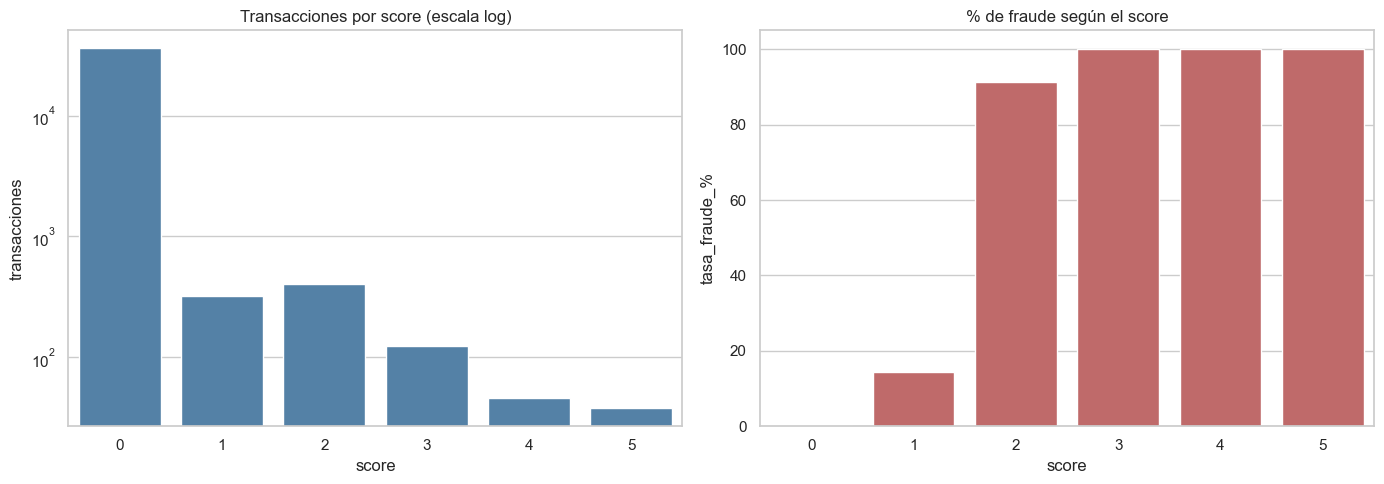

 score  transacciones  fraudes  tasa_fraude_%
     0          35956      102            0.3
     1            325       47           14.5
     2            401      366           91.3
     3            125      125          100.0
     4             46       46          100.0
     5             38       38          100.0


In [23]:
df_base["score"] = df_base[SENALES].sum(axis=1)

por_score = (df_base.groupby("score")
             .agg(transacciones=("es_fraude", "size"), fraudes=("es_fraude", "sum"))
             .reset_index())
por_score["tasa_fraude_%"] = (por_score["fraudes"] / por_score["transacciones"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=por_score, x="score", y="transacciones", color="steelblue", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Transacciones por score (escala log)")

sns.barplot(data=por_score, x="score", y="tasa_fraude_%", color="indianred", ax=axes[1])
axes[1].set_title("% de fraude según el score")
axes[1].set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(por_score.to_string(index=False))


## 3.4 Elección del umbral

Marcar como sospechosa toda transacción con `score >= k`. Con `k` bajo se detecta casi todo el fraude pero con muchas falsas alarmas; con `k` alto al revés. Se elige el umbral con mejor F1 como punto de equilibrio (en un caso real, el negocio decidiría cuántas falsas alarmas puede revisar el equipo de analistas).

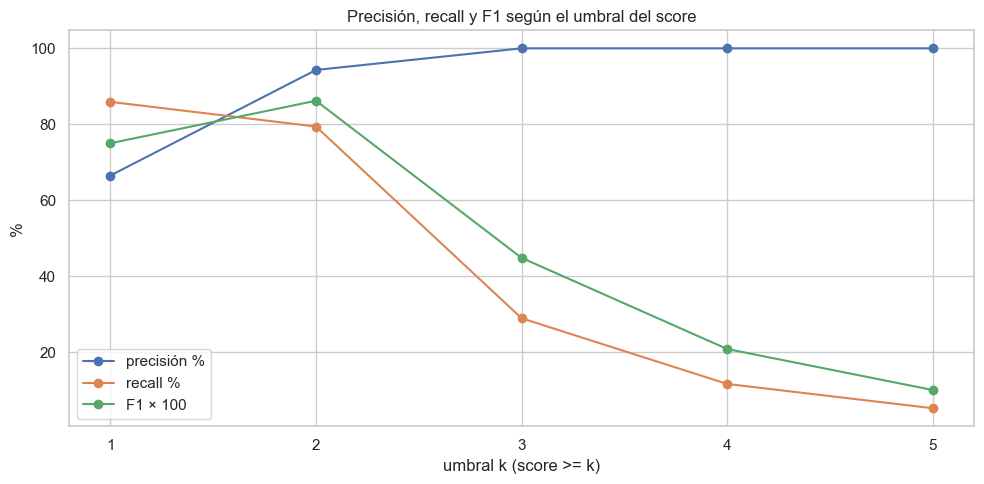

Umbral con mejor F1: score >= 2


,regla,marcadas,fraude_detectado,falsas_alarmas,fraude_escapado,precision_%,recall_%,f1
0,score >= 1,935,622,313,102,66.5,85.9,0.750
1,score >= 2,610,575,35,149,94.3,79.4,0.862
2,score >= 3,209,209,0,515,100.0,28.9,0.448
3,score >= 4,84,84,0,640,100.0,11.6,0.208
4,score >= 5,38,38,0,686,100.0,5.2,0.100


In [24]:
eval_umbrales = pd.DataFrame([
    evaluar_regla(f"score >= {k}", df_base["score"] >= k, df_base["es_fraude"])
    for k in range(1, int(df_base["score"].max()) + 1)
])
eval_umbrales["k"] = range(1, len(eval_umbrales) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eval_umbrales["k"], eval_umbrales["precision_%"], marker="o", label="precisión %")
ax.plot(eval_umbrales["k"], eval_umbrales["recall_%"], marker="o", label="recall %")
ax.plot(eval_umbrales["k"], eval_umbrales["f1"] * 100, marker="o", label="F1 × 100")
ax.set_xticks(eval_umbrales["k"])
ax.set_xlabel("umbral k (score >= k)")
ax.set_ylabel("%")
ax.set_title("Precisión, recall y F1 según el umbral del score")
ax.legend()
plt.tight_layout()
plt.show()

K_OPTIMO = int(eval_umbrales.loc[eval_umbrales["f1"].idxmax(), "k"])
print(f"Umbral con mejor F1: score >= {K_OPTIMO}")
eval_umbrales.drop(columns="k")


## 3.5 Resultado con el umbral elegido

Matriz de confusión y qué tipos de fraude se siguen escapando con el umbral óptimo — justo esos son los que más tendrán que aportar los modelos del Hito 3.

Matriz de confusión (score >= 2):
sospechosa    pred: normal  pred: sospechosa
es_fraude                                   
real: fraude           149               575
real: normal         36132                35


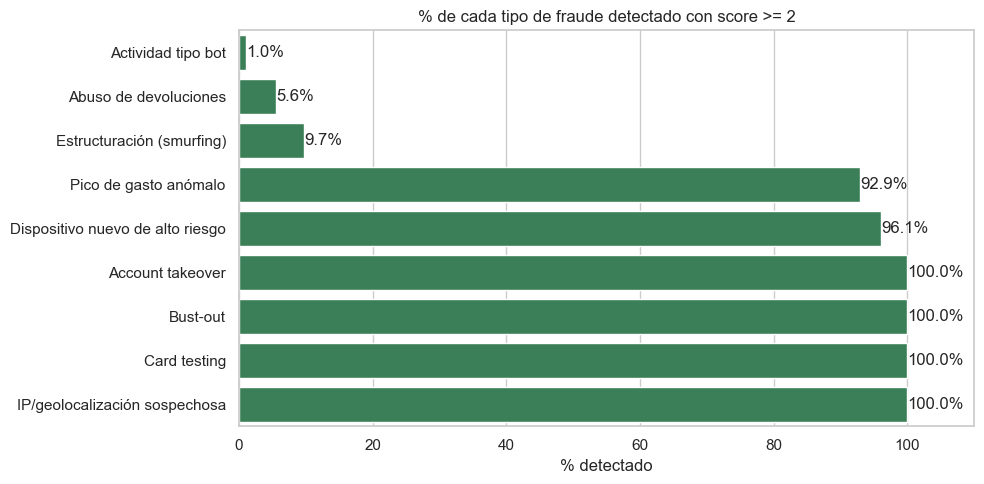

In [25]:
df_base["sospechosa"] = df_base["score"] >= K_OPTIMO

matriz = pd.crosstab(df_base["es_fraude"].map({0: "real: normal", 1: "real: fraude"}),
                     df_base["sospechosa"].map({False: "pred: normal", True: "pred: sospechosa"}))
print(f"Matriz de confusión (score >= {K_OPTIMO}):")
print(matriz.to_string())

recall_patron = (df_base[df_base["es_fraude"] == 1]
                 .groupby("patron")["sospechosa"].mean().mul(100).round(1)
                 .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=recall_patron.values, y=recall_patron.index, color="seagreen", ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%")
ax.set_xlim(0, 110)
ax.set_xlabel("% detectado")
ax.set_ylabel("")
ax.set_title(f"% de cada tipo de fraude detectado con score >= {K_OPTIMO}")
plt.tight_layout()
plt.show()


# 4. Notas para el informe

*Cifras de la ejecución con el dataset por defecto (`dataset_def.py`, `--seed 42`: 36.891 transacciones, 724 fraudulentas = 1,96%). Si se regenera con otra semilla, revisar las tablas de arriba.*

**Outliers univariantes**
- En escala normal, `cantidad` da resultados muy distintos según el método: el Z-score marca solo 250 outliers (0,7%) — casi todos fraude (96,8%), pero detecta solo un 33% del fraude —, mientras que el IQR marca 2.587 (7%), de los que solo un 15,8% es fraude: la cola larga natural de la lognormal genera muchas falsas alarmas.
- Aplicando el **logaritmo** antes de buscar outliers la distribución pasa a ser aproximadamente normal y ambos métodos mejoran mucho: el IQR en escala log marca 790 outliers, el 73% son fraude y detecta casi el 80% del fraude, incluidos importes anormalmente **bajos** (< 3,30€, típicos del *card testing*) que en escala normal eran invisibles.
- `num_intentos_login` tiene IQR = 0 (casi todo vale 1): cualquier valor mayor sale como outlier; hay 45 sesiones con 4-7 intentos. `limite_credito` y `nota_riesgo` no tienen outliers, lo que confirma que los datos se generaron dentro de sus rangos.

**Patrones simples de fraude**
- **Picos de gasto** (z robusto de log(importe) por cliente, umbral 3,5): 314 transacciones marcadas, precisión 57%, recall 25%. Detecta el 100% del bust-out, 93% de los picos de gasto, 84% de account takeover y 71% de dispositivo nuevo. Tiene más falsas alarmas que el análisis global porque cada cliente solo tiene ~18 transacciones y su mediana/MAD se estiman con poco historial.
- **Ráfagas** (≥ 5 transacciones con la misma tarjeta separadas < 60 s): 33 ráfagas, 275 transacciones, precisión 100%. Detecta el 100% del *card testing* y ningún otro tipo: es una regla muy específica.

**Técnicas estadísticas para detección de anomalías**
- Se combinan 7 señales estadísticas en un score (0-7). La tasa de fraude sube de forma muy marcada con el score: 0,3% (score 0) → 14,5% (1) → 91,3% (2) → 100% (3 o más).
- Con el umbral óptimo (**score ≥ 2**): precisión 94,3%, recall 79,4%, F1 0,86 — solo 35 falsas alarmas entre 36.167 transacciones normales, y 149 fraudes que se escapan.
- Los tipos que casi no se detectan son **actividad tipo bot** (1%), **abuso de devoluciones** (6%) y **smurfing** (10%): ninguna de las señales mira la velocidad de eventos dentro de la sesión (tabla `evento`), las devoluciones rápidas (tabla `devolucion`) ni importes repetidos justo bajo un umbral a lo largo de varias horas. Son los candidatos para el feature engineering del Hito 3.

**Limitación importante**: los datos son sintéticos y las reglas de generación son muy "limpias" (p. ej. el VPN o los países raros solo aparecen en sesiones fraudulentas), por eso varias señales tienen precisión del 100%. Con datos reales habría más solapamiento entre normal y fraude, y estas cifras deben tomarse como una referencia optimista, no como el rendimiento esperado en producción.